In [92]:
import numpy as np

from shrec.models import RecurrenceManifold
import matplotlib.pyplot as plt

from cdriver.datagen.logmap import gen_logmapdata
from cdriver.preprocessing.splitters import train_valid_test_split
from cdriver.evaluate.evalz import comp_ccorr, get_maxes

%matplotlib inline

In [130]:
# generate data
params = dict(N=1,  # number of realizations
              n=10_000,  # Length of time series
              rint=(3.8, 4.),  # interval to chose from the value of r parameter
              A0=np.array([[0, 0, 0],
                           [1, 0, 0],
                           [1, 0, 0]]), # basic connection structure
              A=np.array([[1., 0., 0.],
                          [0.3, 1., 0.],
                          [0.4, 0., 1.]])
                          )

dataset, _ = gen_logmapdata(params)

data = dataset[0]
X = data[:, 1:]
z = data[:, 0]

X_train, _, z_train, X_valid, _valid, z_valid, X_test, __, z_test = train_valid_test_split(X, X, z, 0.5, 0)

print(z_train.shape)


Generating dataset: 100%|██████████| 1/1 [00:00<00:00,  6.48it/s]

(5000,)


In [131]:
model = RecurrenceManifold(d_embed=2)

z_pred = model.fit_predict(X_train)

<>:17: SyntaxWarning: invalid escape sequence '\h'
<>:19: SyntaxWarning: invalid escape sequence '\h'
<>:21: SyntaxWarning: invalid escape sequence '\h'
<>:23: SyntaxWarning: invalid escape sequence '\h'
<>:17: SyntaxWarning: invalid escape sequence '\h'
<>:19: SyntaxWarning: invalid escape sequence '\h'
<>:21: SyntaxWarning: invalid escape sequence '\h'
<>:23: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_3059875/2321729433.py:17: SyntaxWarning: invalid escape sequence '\h'
  _ = ax1.set_title('$z_t$ vs. $\hat{z}_{t+'+str(l)+'}$')
/tmp/ipykernel_3059875/2321729433.py:19: SyntaxWarning: invalid escape sequence '\h'
  _ = ax1.set_ylabel('$\hat{z}_{t+'+str(l)+'}$')
/tmp/ipykernel_3059875/2321729433.py:21: SyntaxWarning: invalid escape sequence '\h'
  _ = ax2.set_title('$\hat{z}_t$ vs. $z_{t+'+str(l)+'}$')
/tmp/ipykernel_3059875/2321729433.py:23: SyntaxWarning: invalid escape sequence '\h'
  _ = ax2.set_ylabel('$\hat{z}_{t}$')


(-2, 0.7087177078741211)


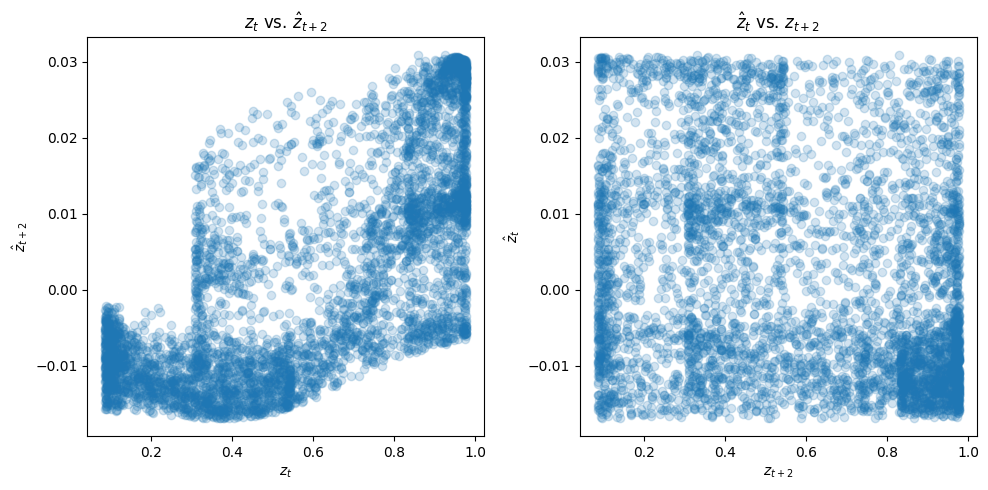

In [132]:
n = len(z_train)



tau, c = comp_ccorr(z_train, z_pred)
mc = get_maxes(tau, c)
print(mc)

l = np.abs(mc[0])


fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 5))

_ = ax1.scatter(z_train[:n-l], z_pred[l:], alpha=0.2)
_ = ax2.scatter(z_train[l:], z_pred[:n-l], alpha=0.2)

_ = ax1.set_title('$z_t$ vs. $\hat{z}_{t+'+str(l)+'}$')
_ = ax1.set_xlabel('$z_t$')
_ = ax1.set_ylabel('$\hat{z}_{t+'+str(l)+'}$')

_ = ax2.set_title('$\hat{z}_t$ vs. $z_{t+'+str(l)+'}$')
_ = ax2.set_xlabel('$z_{t+2}$')
_ = ax2.set_ylabel('$\hat{z}_{t}$')

_ = fig.tight_layout()

In [133]:
# There is no predict method for this model so we cannot simply predict the test set, without fitting the model again :(
model.fit(X_train)
model.predict(X_test)

AttributeError: 'RecurrenceManifold' object has no attribute 'predict'